In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

<p>Determine the maximum deflection of a cantilever beam subjected to a UDL using Python.</p>
<img src="https://lh3.googleusercontent.com/d/1JQ5sjDBVe7jyNjjTsZt4FF8Gg_26b0YB" width="400" />

In [3]:
# data
p1 = 4000 # N
p2 = 2000 # N
l = 4 # m
e = 200e9 # Pa
i = 1e-6 # m^4

def cant_beam(u,x):
    u1, u2 = u
    du1dx = u2
    if x <= 2:
        m = -p1*(4-x) - p2*(2-x)
    else:
        m = -p1*(4-x)
    du2dx = m/(e*i)
    return du1dx, du2dx

initial_condition = [0,0]
x_value = np.linspace(0,l,100)

solution = sp.integrate.odeint(cant_beam, initial_condition, x_value)

deflection = solution.T[0]
rotation = solution.T[1]

print('Deflection', min(deflection))
print('rotation', min(rotation))

Deflection -0.49333338122971093
rotation -0.18000003037805823


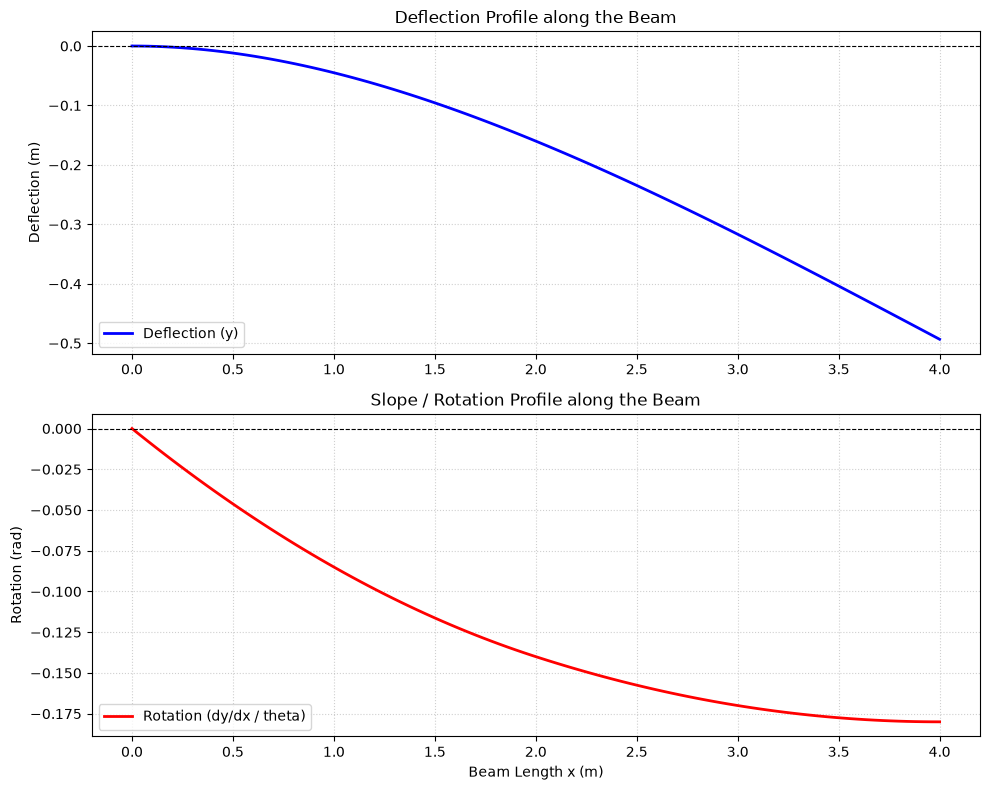

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# deflection
plt.subplot(2, 1, 1)
plt.plot(x_value, deflection, color="b", linewidth=2, label="Deflection (y)")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.ylabel("Deflection (m)")  
plt.title("Deflection Profile along the Beam") 
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# rotation
plt.subplot(2, 1, 2)  
plt.plot(
    x_value, rotation, color="r", linewidth=2, label="Rotation (dy/dx / theta)"
)
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("Beam Length x (m)") 
plt.ylabel("Rotation (rad)") 
plt.title("Slope / Rotation Profile along the Beam") 
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()